# Prediction of Employee Attrition using Random Forest and Extreme Gradient Boosting on the Employee Attrition Classification Dataset

**Group 6 - 3CSD - Final Project**

**Project Objective.** This project develops a comparative employee attrition prediction system using the Employee Attrition Classification Dataset by evaluating baseline models, a deep learning model, and state-of-the-art tree-based ensemble models. Logistic Regression and CART serve as baseline classifiers, a Deep Neural Network represents the deep learning approach, and Random Forest with XGBoost represents the primary high-performance modeling approach of the project.

The study incorporates cost-sensitive optimization to reflect the business impact of attrition prediction errors. Because failing to identify an employee who is likely to leave can create higher organizational costs through recruitment, replacement, and retraining, false negatives are assigned a greater penalty than false positives. This makes the model more responsive to potential flight-risk employees, even if it occasionally flags employees who may ultimately stay.

Beyond predictive accuracy, the project emphasizes explainable and actionable HR decision support. Although deep learning models may achieve competitive performance, HR stakeholders require interpretable evidence for why an employee is classified as retaining or flight-risk. Therefore, SHAP is used to explain the Random Forest and XGBoost predictions, while DiCE is used to generate counterfactual prescriptions that suggest possible interventions for helping flight-risk employees remain with the organization.

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                            roc_auc_score, average_precision_score)

import xgboost as xgb

# DNN
import tensorflow as tf
from tensorflow.keras import layers, models as kmodels, callbacks

import shap
import dice_ml
import joblib

# Config
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

print(f'TensorFlow {tf.__version__}\nXGBoost {xgb.__version__}\nSHAP {shap.__version__}')

c:\Users\Niko\Documents\3CSD\2nd Semester\Machine Learning\Final Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow 2.21.0
XGBoost 3.2.0
SHAP 0.51.0


## Step 1 -- Data Preparation and Feature Engineering

This step imports the training and testing datasets, removes non-predictive identifiers, encodes the target variable, and separates categorical variables according to their measurement properties. Ordinal features are encoded using their natural order, nominal features are one-hot encoded, and numerical variables are standardized. A validation subset is also created from the training data so that threshold selection and model development decisions remain independent from the final test evaluation.

In [2]:
DATA_DIR   = './data'
TRAIN_PATH = os.path.join(DATA_DIR, 'train.csv')
TEST_PATH  = os.path.join(DATA_DIR, 'test.csv')

assert os.path.exists(TRAIN_PATH), f'Missing training file: {TRAIN_PATH}'
assert os.path.exists(TEST_PATH),  f'Missing testing file:  {TEST_PATH}'

df_train_raw = pd.read_csv(TRAIN_PATH)
df_test_raw  = pd.read_csv(TEST_PATH)

print('Train shape:', df_train_raw.shape)
print('Test shape: ', df_test_raw.shape)
print('\nColumns:\n ', list(df_train_raw.columns))

Train shape: (59598, 24)
Test shape:  (14900, 24)

Columns:
  ['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']


In [3]:
# Cleaning and preprocessing
df_train = df_train_raw.drop(columns=['Employee ID']).copy()
df_test  = df_test_raw.drop(columns=['Employee ID']).copy()

df_train['Attrition'] = df_train['Attrition'].map({'Stayed': 0, 'Left': 1})
df_test['Attrition']  = df_test['Attrition'].map({'Stayed': 0, 'Left': 1})

# Separate features and target
X_ftrain = df_train.drop(columns=['Attrition'])
y_ftrain = df_train['Attrition']

X_test = df_test.drop(columns=['Attrition'])
y_test = df_test['Attrition']

# Train / validation split (80/20, stratified)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_ftrain, y_ftrain,
    test_size=0.2, stratify=y_ftrain, random_state=SEED
)

# Columns already in numerical form
numerical_cols = [
    'Age', 'Years at Company', 'Monthly Income', 'Number of Promotions',
    'Distance from Home', 'Number of Dependents', 'Company Tenure'
]

# Columns with natural ordering 
ordinal_cols = [
    'Work-Life Balance', 'Job Satisfaction', 'Performance Rating',
    'Education Level', 'Job Level', 'Company Size',
    'Company Reputation', 'Employee Recognition'
]
ordinal_categories = [
    ['Poor', 'Fair', 'Good', 'Excellent'],                                              # Work-Life Balance
    ['Low', 'Medium', 'High', 'Very High'],                                             # Job Satisfaction
    ['Low', 'Below Average', 'Average', 'High'],                                        # Performance Rating
    ['High School', 'Associate Degree', "Bachelor’s Degree", "Master’s Degree", 'PhD'], # Education Level
    ['Entry', 'Mid', 'Senior'],                                                         # Job Level
    ['Small', 'Medium', 'Large'],                                                       # Company Size
    ['Poor', 'Fair', 'Good', 'Excellent'],                                              # Company Reputation
    ['Low', 'Medium', 'High', 'Very High'],                                             # Employee Recognition
]

# Columns with no ordering
nominal_cols = [
    'Gender', 'Job Role', 'Overtime', 'Marital Status',
    'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities'
]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('ord', OrdinalEncoder(categories=ordinal_categories,
                           handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
])

X_tr_prcsd = preprocessor.fit_transform(X_tr)
X_val_prcsd  = preprocessor.transform(X_val)
X_test_prcsd = preprocessor.transform(X_test)

print(f"X_tr: {X_tr_prcsd.shape}")
print(f"X_val: {X_val_prcsd.shape}")
print(f"X_test: {X_test_prcsd.shape}")
print(f"\nClass balance (train): {y_tr.value_counts(normalize=True).round(3).to_dict()}")
print(f"Class balance (test): {y_test.value_counts(normalize=True).round(3).to_dict()}")

X_tr: (47678, 33)
X_val: (11920, 33)
X_test: (14900, 33)

Class balance (train): {0: 0.525, 1: 0.475}
Class balance (test): {0: 0.528, 1: 0.472}


## Step 2 -- Baseline Model Development

This step trains the initial set of candidate models using their default classification objectives and without any cost-sensitive adjustments. The baseline stage provides a controlled reference point for measuring later improvements from threshold optimization, cost-aware training, and hyperparameter tuning.

The baseline comparison includes linear, tree-based, ensemble, and neural network approaches so that the project can evaluate both interpretable and higher-capacity modeling strategies.

**Branch A -- Baseline Models**

In [4]:
log_reg = LogisticRegression(max_iter=1000, random_state=SEED)
log_reg.fit(X_tr_prcsd, y_tr)

cart_tree = DecisionTreeClassifier(random_state=SEED, max_depth=10)
cart_tree.fit(X_tr_prcsd, y_tr)

print("Baselines (LogReg, CART) trained on X_tr.")

Baselines (LogReg, CART) trained on X_tr.


**Branch B -- Deep Neural Network**

In [5]:
dnn_model = kmodels.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_tr_prcsd.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Stop training after 5 epochs of no improvement
es_callback = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Training DNN...")
dnn_history = dnn_model.fit(
    X_tr_prcsd, y_tr,
    validation_data=(X_val_prcsd, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[es_callback],
    verbose=1
)

Training DNN...
Epoch 1/50
745/745 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7106 - loss: 0.5495 - val_accuracy: 0.7375 - val_loss: 0.5051
Epoch 2/50
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7379 - loss: 0.5126 - val_accuracy: 0.7402 - val_loss: 0.4987
Epoch 3/50
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7430 - loss: 0.5043 - val_accuracy: 0.7424 - val_loss: 0.4952
Epoch 4/50
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7465 - loss: 0.4994 - val_accuracy: 0.7408 - val_loss: 0.4935
Epoch 5/50
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7478 - loss: 0.4967 - val_accuracy: 0.7428 - val_loss: 0.4930
Epoch 6/50
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7484 - loss: 0.4937 - val_accuracy: 0.7409 - val_loss: 0.4913
Epoch 7/50
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7506 - loss: 0.4913 - val_accuracy: 0.7419 - val_loss: 0.4909
Epoch 8/50
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7498 - loss: 0.4904 - 

**Branch C -- Ensembles**

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X_tr_prcsd, y_tr)

xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=SEED, n_jobs=-1)
xgb_model.fit(X_tr_prcsd, y_tr)

baseline_ensemble = VotingClassifier(
    estimators=[('Random Forest', rf_model), ('XGBoost', xgb_model)],
    voting='soft',
)
baseline_ensemble.fit(X_tr_prcsd, y_tr)

print("Random Forest, XGBoost, and baseline Voting Ensemble trained on X_tr.")
print("All baseline models trained on X_tr.")

Random Forest, XGBoost, and baseline Voting Ensemble trained on X_tr.
All baseline models trained on X_tr.


## Step 3 -- Baseline Performance Benchmark

This step evaluates each baseline model on the held-out test set using accuracy, precision, recall, F1-score, and confusion matrices. The benchmark establishes the initial performance profile of each classifier, with particular attention to recall for the attrition class because missed attrition cases are more costly for HR planning.

In [7]:
baseline_models = {
    "Logistic Regression": log_reg,
    "CART Tree": cart_tree,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Voting Ensemble": baseline_ensemble,
}

baseline_metrics = {}
results = []

# Branch A and C
for name, model in baseline_models.items():
    y_pred = model.predict(X_test_prcsd)
    baseline_metrics[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_left': precision_score(y_test, y_pred),
        'recall_left': recall_score(y_test, y_pred),
        'f1_left': f1_score(y_test, y_pred),
    }
    results.append((name, *baseline_metrics[name].values()))

# Branch B
dnn_probs = dnn_model.predict(X_test_prcsd, verbose=0).flatten()
dnn_pred = (dnn_probs >= 0.5).astype(int)
baseline_metrics["TensorFlow DNN"] = {
    'accuracy': accuracy_score(y_test, dnn_pred),
    'precision_left': precision_score(y_test, dnn_pred),
    'recall_left': recall_score(y_test, dnn_pred),
    'f1_left': f1_score(y_test, dnn_pred),
}
results.append(("TensorFlow DNN", *baseline_metrics["TensorFlow DNN"].values()))

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision (Left)', 'Recall (Left)', 'F1 (Left)']
).sort_values(by='F1 (Left)', ascending=False)

display(results_df)
print("\nRecall on 'Left' caps around ~0.74 -- we miss ~26% of leavers.")
print("Step 4 introduces the cost matrix; Steps 5-6 attack this gap from two angles.")

,Model,Accuracy,Precision (Left),Recall (Left),F1 (Left)
5,TensorFlow DNN,0.749060,0.722110,0.761234,0.741156
3,XGBoost,0.751678,0.734450,0.742179,0.738294
4,Voting Ensemble,0.752215,0.737283,0.737912,0.737598
2,Random Forest,0.749799,0.739559,0.725256,0.732338
0,Logistic Regression,0.743221,0.732050,0.719141,0.725538
1,CART Tree,0.735638,0.720708,0.718146,0.719424



Recall on 'Left' caps around ~0.74 -- we miss ~26% of leavers.
Step 4 introduces the cost matrix; Steps 5-6 attack this gap from two angles.


## Step 4 -- Cost Matrix Definition

This step formalizes the business cost of classification errors. False negatives, which represent employees predicted to stay but who actually leave, are assigned a higher penalty than false positives because they can result in missed retention opportunities. The resulting cost matrix is used in later steps for threshold selection and cost-sensitive model training.

In [8]:
COST_FN = 2
COST_FP = 1

def calculate_custom_cost(y_true, y_pred_probs, threshold):
    preds = (y_pred_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    total_cost = (fn * COST_FN) + (fp * COST_FP)
    return total_cost, fn, fp

print(f"Cost Matrix Defined: \n     False Negative Penalty = {COST_FN}x\n     False Positive Penalty = {COST_FP}x")

Cost Matrix Defined: 
     False Negative Penalty = 2x
     False Positive Penalty = 1x


## Step 5 -- Threshold-Only Optimization

This step performs a threshold-only ablation using the baseline models from Step 2. The model parameters are intentionally kept fixed while the decision threshold is selected on the validation set to minimize the custom cost from Step 4.

Although Step 7 later retrains and tunes the models, this step remains useful because it separates the effect of inference-time threshold calibration from the effect of model retraining. It also demonstrates whether the baseline models already produce useful probability rankings and provides a cost-optimized threshold benchmark. The final deployment threshold is still selected after the tuned models are trained in Step 7.

In [9]:
def get_proba(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    return model.predict(X, verbose=0).flatten()

# For each model, pick the cost-minimizing threshold on val (0.10 - 0.90 on 0.01 increments)
def tune_threshold_per_model(models, X_val_, X_test_, y_val_, y_test_):
    out = {}
    for name, model in models.items():
        val_probs  = get_proba(model, X_val_)
        test_probs = get_proba(model, X_test_)
        best_t, best_c = 0.5, float('inf')
        for t in np.arange(0.10, 0.90, 0.01):
            c, _, _ = calculate_custom_cost(y_val_, val_probs, t)
            if c < best_c:
                best_c, best_t = c, t
        test_pred = (test_probs >= best_t).astype(int)
        out[name] = {
            'accuracy': accuracy_score(y_test_, test_pred),
            'precision_left': precision_score(y_test_, test_pred),
            'recall_left': recall_score(y_test_, test_pred),
            'f1_left': f1_score(y_test_, test_pred),
            'best_threshold': best_t,
        }
    return out

# Reuse step-2 models
baseline_for_thresh = {
    'Logistic Regression': log_reg,
    'CART Tree': cart_tree,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'TensorFlow DNN': dnn_model,
    'Voting Ensemble': baseline_ensemble,
}

threshold_only_metrics = tune_threshold_per_model(
    baseline_for_thresh, X_val_prcsd, X_test_prcsd, y_val, y_test
)

# Step 3 benchmark table with tuned thresholds
results_a = []
for name, m in threshold_only_metrics.items():
    results_a.append((
        name,
        m['accuracy'], m['precision_left'], m['recall_left'], m['f1_left'],
        m['best_threshold'],
    ))
df_a = pd.DataFrame(
    results_a,
    columns=['Model', 'Accuracy', 'Precision (Left)', 'Recall (Left)', 'F1 (Left)', 'Threshold']
).sort_values(by='F1 (Left)', ascending=False)

display(df_a)

,Model,Accuracy,Precision (Left),Recall (Left),F1 (Left),Threshold
5,Voting Ensemble,0.718859,0.643138,0.908276,0.753051,0.31
2,Random Forest,0.719597,0.648399,0.886661,0.749039,0.36
3,XGBoost,0.708993,0.632209,0.916667,0.748317,0.25
4,TensorFlow DNN,0.701544,0.623389,0.928612,0.745987,0.29
0,Logistic Regression,0.706376,0.632466,0.902019,0.743567,0.29
1,CART Tree,0.707315,0.637411,0.880973,0.739657,0.33


## Step 6 -- Cost-Aware Training Configuration

This step converts the project cost matrix into model-specific training inputs. For scikit-learn and Keras models, the positive attrition class receives a larger class weight. For XGBoost, the same cost preference is represented through `scale_pos_weight`. These settings guide the training algorithms to place greater emphasis on identifying employees who are likely to leave.

In [10]:
COST_WEIGHTS = {0: 1, 1: 2}

print(f"Cost weights for sklearn-style models: {COST_WEIGHTS}")
print(f"Equivalent XGBoost setting: scale_pos_weight={COST_WEIGHTS[1] / COST_WEIGHTS[0]}")

Cost weights for sklearn-style models: {0: 1, 1: 2}
Equivalent XGBoost setting: scale_pos_weight=2.0


## Step 7 -- Cost-Aware Hyperparameter Tuning and Retraining

This step retrains the candidate models using both the cost-aware settings from Step 6 and hyperparameter search. These two procedures are performed together because the best hyperparameter configuration can change once the learning objective gives greater importance to the attrition class.

Logistic Regression, CART, Random Forest, and XGBoost are tuned through cross-validated randomized search scored by F1-score. The neural network is tuned through a small manual architecture grid with validation monitoring. After retraining, an optimized soft-voting ensemble is constructed from the tuned Random Forest and XGBoost models, and each tuned model receives its own validation-selected decision threshold.

In [11]:
print("Tuning Logistic Regression...")
lr_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
}
lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=SEED, class_weight=COST_WEIGHTS),
    lr_grid, n_iter=4, cv=3, scoring='f1', random_state=SEED, n_jobs=-1,
)
lr_search.fit(X_tr_prcsd, y_tr)
best_lr = lr_search.best_estimator_
print(f"    Best LR: {lr_search.best_params_}")


print("Tuning CART...")
cart_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
}
cart_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=SEED, class_weight=COST_WEIGHTS),
    cart_grid, n_iter=10, cv=3, scoring='f1', random_state=SEED, n_jobs=-1,
)
cart_search.fit(X_tr_prcsd, y_tr)
best_cart = cart_search.best_estimator_
print(f"    Best CART: {cart_search.best_params_}")


print("Tuning Random Forest...")
rf_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'class_weight':      [{0: 1, 1: 2}, 'balanced'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    rf_grid, n_iter=10, cv=3, scoring='f1', random_state=SEED, n_jobs=-1,
)
rf_search.fit(X_tr_prcsd, y_tr)
best_rf = rf_search.best_estimator_
print(f"    Best RF: {rf_search.best_params_}")


print("Tuning XGBoost...")
xgb_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'scale_pos_weight': [2.0],
}
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=SEED),
    xgb_grid, n_iter=10, cv=3, scoring='f1', random_state=SEED, n_jobs=-1,
)
xgb_search.fit(X_tr_prcsd, y_tr)
best_xgb = xgb_search.best_estimator_
print(f"    Best XGB: {xgb_search.best_params_}")


print("Tuning DNN...")
dnn_configs = [
    {'units1': 64, 'units2': 32, 'dropout': 0.2},
    {'units1': 128, 'units2': 64, 'dropout': 0.3},
    {'units1': 32, 'units2': 16, 'dropout': 0.1},
]
best_dnn, best_dnn_cfg, best_dnn_f1 = None, None, -1.0
for cfg in dnn_configs:
    m = kmodels.Sequential([
        layers.Dense(cfg['units1'], activation='relu', input_shape=(X_tr_prcsd.shape[1],)),
        layers.Dropout(cfg['dropout']),
        layers.Dense(cfg['units2'], activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    m.fit(
        X_tr_prcsd, y_tr,
        validation_data=(X_val_prcsd, y_val),
        class_weight=COST_WEIGHTS,
        epochs=50, batch_size=64,
        callbacks=[es], verbose=0,
    )
    val_pred = (m.predict(X_val_prcsd, verbose=0).flatten() >= 0.5).astype(int)
    val_f1 = f1_score(y_val, val_pred)
    if val_f1 > best_dnn_f1:
        best_dnn, best_dnn_cfg, best_dnn_f1 = m, cfg, val_f1
print(f"    Best DNN: {best_dnn_cfg} (val F1: {best_dnn_f1:.3f})")

print("\nAll 5 models hp-tuned with cost-aware settings.")

Tuning Logistic Regression...
    Best LR: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}
Tuning CART...
    Best CART: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}
Tuning Random Forest...
    Best RF: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10, 'class_weight': {0: 1, 1: 2}}
Tuning XGBoost...
    Best XGB: {'subsample': 0.8, 'scale_pos_weight': 2.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Tuning DNN...
    Best DNN: {'units1': 64, 'units2': 32, 'dropout': 0.2} (val F1: 0.756)

All 5 models hp-tuned with cost-aware settings.


In [12]:
# Build the tuned ensemble from the tuned RF + XGB
tuned_ensemble = VotingClassifier(
    estimators=[('Random Forest', best_rf), ('XGBoost', best_xgb)],
    voting='soft',
)
tuned_ensemble.fit(X_tr_prcsd, y_tr)

# Tune threshold per hp-tuned model on val
stage_b_models = {
    'Logistic Regression': best_lr,
    'CART Tree': best_cart,
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'TensorFlow DNN': best_dnn,
    'Voting Ensemble': tuned_ensemble,
}

cost_aware_metrics = tune_threshold_per_model(
    stage_b_models, X_val_prcsd, X_test_prcsd, y_val, y_test
)

# For final step
ensemble_metrics = cost_aware_metrics['Voting Ensemble']
best_threshold_ens = ensemble_metrics['best_threshold']
ensemble_test_probs = tuned_ensemble.predict_proba(X_test_prcsd)[:, 1]

# Stage B benchmark table (Step-3 format + chosen threshold)
results_b = []
for name, m in cost_aware_metrics.items():
    results_b.append((
        name,
        m['accuracy'], m['precision_left'], m['recall_left'], m['f1_left'],
        m['best_threshold'],
    ))
df_b = pd.DataFrame(
    results_b,
    columns=['Model', 'Accuracy', 'Precision (Left)', 'Recall (Left)', 'F1 (Left)', 'Threshold']
).sort_values(by='F1 (Left)', ascending=False)

display(df_b)

,Model,Accuracy,Precision (Left),Recall (Left),F1 (Left),Threshold
3,XGBoost,0.728188,0.653743,0.901593,0.757920,0.49
5,Voting Ensemble,0.720403,0.644339,0.909699,0.754363,0.49
4,TensorFlow DNN,0.717114,0.641629,0.907423,0.751723,0.50
2,Random Forest,0.707651,0.630792,0.917662,0.747654,0.49
0,Logistic Regression,0.706510,0.632566,0.902162,0.743684,0.45
1,CART Tree,0.693893,0.621545,0.898464,0.734779,0.45


## Step 8 -- Final Model Comparison and Business Impact Assessment

This step compares the three experimental stages: the default baseline models, the threshold-optimized baseline models, and the cost-aware hyperparameter-tuned models. Each performance metric is plotted separately to improve readability and to make metric-specific trade-offs easier to interpret.

The comparison is followed by two complementary analyses on the tuned models:

1. **Business cost analysis** -- applies the project cost matrix (FN penalty `COST_FN`, FP penalty `COST_FP`) to each tuned model at its validation-selected threshold, then ranks the models by total weighted cost. This is the operational decision metric used to choose a model for deployment.
2. **Calibration analysis** -- reports threshold-independent ROC-AUC and PR-AUC for each tuned model. Unlike the weighted cost ranking, these metrics ignore the cost structure and instead diagnose probability ranking quality, which indicates how trustworthy a model's probability estimates are at any threshold.

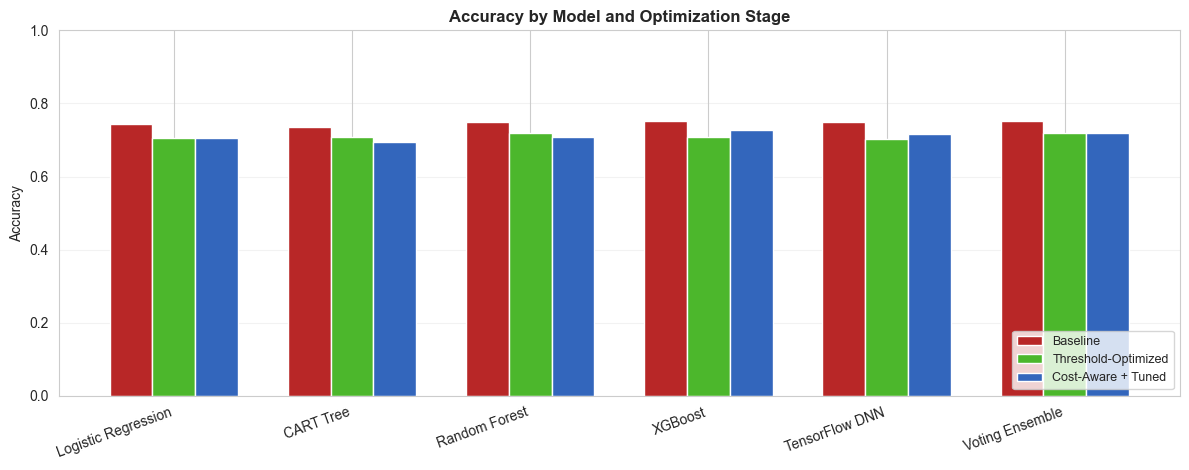

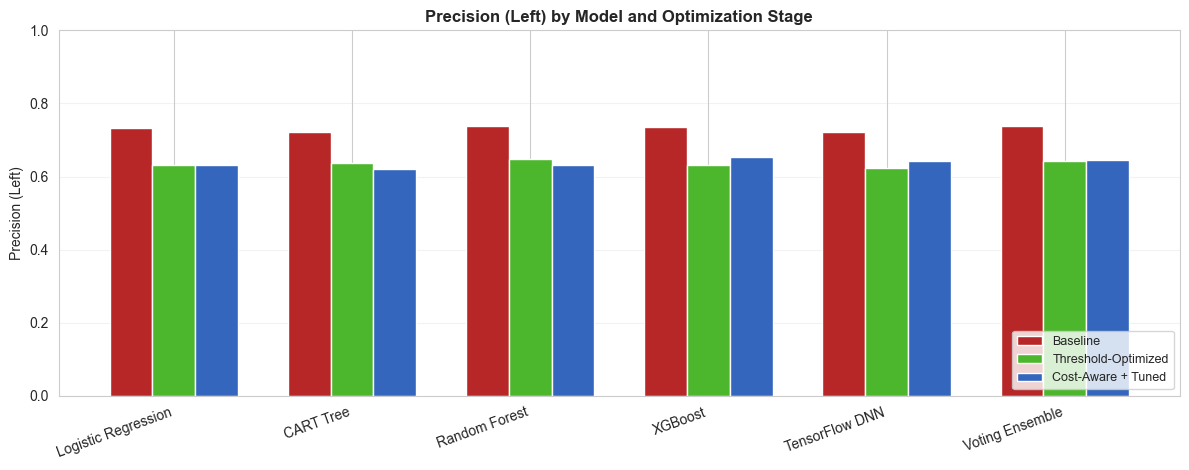

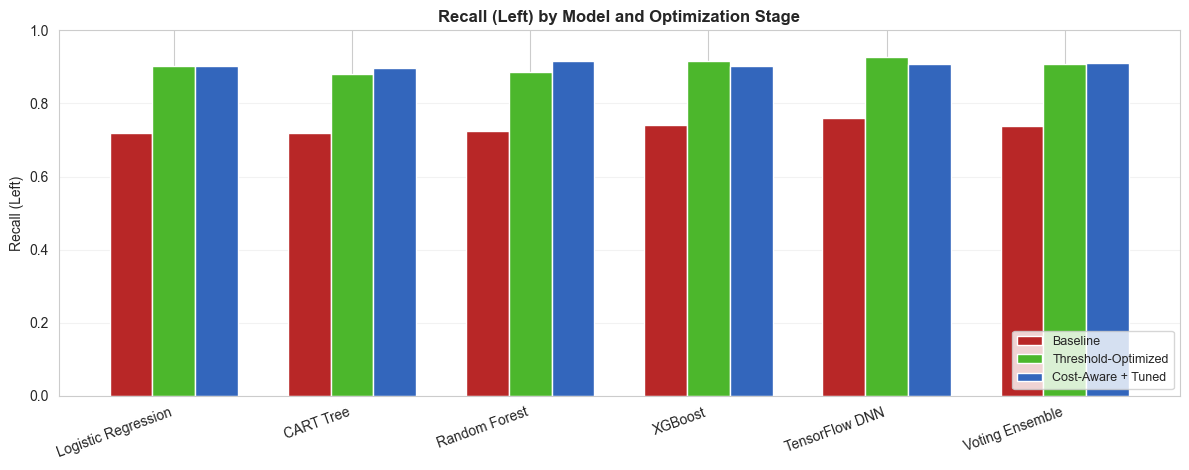

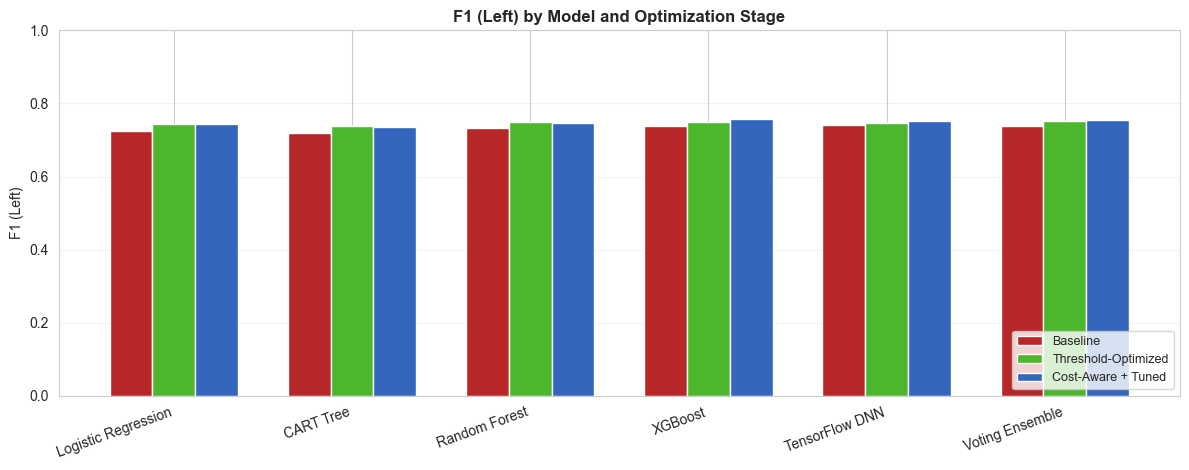


Recall improvement attribution by model:


,Model,Recall (Baseline),Recall (Threshold-Optimized),Recall (Cost-Aware + Tuned),Change from Threshold Selection,Change from Cost-Aware Tuning,Total Recall Change
0,Logistic Regression,0.719,0.902,0.902,+0.183,+0.000,+0.183
1,CART Tree,0.718,0.881,0.898,+0.163,+0.017,+0.180
2,Random Forest,0.725,0.887,0.918,+0.161,+0.031,+0.192
3,XGBoost,0.742,0.917,0.902,+0.174,-0.015,+0.159
4,TensorFlow DNN,0.761,0.929,0.907,+0.167,-0.021,+0.146
5,Voting Ensemble,0.738,0.908,0.910,+0.170,+0.001,+0.172


In [13]:
models_order = [
    'Logistic Regression', 'CART Tree', 'Random Forest', 'XGBoost', 'TensorFlow DNN', 'Voting Ensemble',
]
metrics_to_plot = [
    ('accuracy', 'Accuracy'),
    ('precision_left', 'Precision (Left)'),
    ('recall_left', 'Recall (Left)'),
    ('f1_left', 'F1 (Left)'),
]

stage_labels = ['Baseline', 'Threshold-Optimized', 'Cost-Aware + Tuned']
stage_colors = ["#B82727", "#4CB72C", "#3366BC"]
x = np.arange(len(models_order))
width = 0.24

for key, title in metrics_to_plot:
    base_vals = [baseline_metrics[m][key] for m in models_order]
    a_vals = [threshold_only_metrics[m][key] for m in models_order]
    b_vals = [cost_aware_metrics[m][key] for m in models_order]

    fig, ax = plt.subplots(figsize=(12, 4.8))
    ax.bar(x - width, base_vals, width, label=stage_labels[0], color=stage_colors[0])
    ax.bar(x, a_vals, width, label=stage_labels[1], color=stage_colors[1])
    ax.bar(x + width, b_vals, width, label=stage_labels[2], color=stage_colors[2])

    ax.set_title(f'{title} by Model and Optimization Stage', fontsize=12, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_xticks(x)
    ax.set_xticklabels(models_order, rotation=20, ha='right')
    ax.set_ylim(0, 1.0)
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

# Recall-gain attribution table
attr_rows = []
for m in models_order:
    base = baseline_metrics[m]['recall_left']
    a = threshold_only_metrics[m]['recall_left']
    b = cost_aware_metrics[m]['recall_left']
    attr_rows.append({
        'Model': m,
        'Recall (Baseline)': f"{base:.3f}",
        'Recall (Threshold-Optimized)': f"{a:.3f}",
        'Recall (Cost-Aware + Tuned)': f"{b:.3f}",
        'Change from Threshold Selection': f"{a-base:+.3f}",
        'Change from Cost-Aware Tuning': f"{b-a:+.3f}",
        'Total Recall Change': f"{b-base:+.3f}",
    })

print("\nRecall improvement attribution by model:")
display(pd.DataFrame(attr_rows))

In [14]:
# Business impact for the SOTA (Optimized Voting Ensemble) model
final_preds = (ensemble_test_probs >= best_threshold_ens).astype(int)
cm = confusion_matrix(y_test, final_preds)

print(f"Optimized Voting Ensemble -- Test Performance @ Threshold {best_threshold_ens:.2f}")
print(classification_report(y_test, final_preds, target_names=['Stayed (0)', 'Left (1)']))

print("Final Business Impact (Confusion Matrix on Test Set):")
print(f"    Correctly Retained (TN):                    {cm[0][0]}")
print(f"    Unnecessary Bonuses (FP, minor loss):       {cm[0][1]}")
print(f"    Unexpected Leavers (FN, MAJOR loss):        {cm[1][0]}")
print(f"    Correctly Flagged Leavers (TP):             {cm[1][1]}")
print(f"\nTotal cost penalty (test):                    {cm[1][0]*COST_FN + cm[0][1]*COST_FP}")

Optimized Voting Ensemble -- Test Performance @ Threshold 0.49
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.55      0.68      7868
    Left (1)       0.64      0.91      0.75      7032

    accuracy                           0.72     14900
   macro avg       0.76      0.73      0.71     14900
weighted avg       0.76      0.72      0.71     14900

Final Business Impact (Confusion Matrix on Test Set):
    Correctly Retained (TN):                    4337
    Unnecessary Bonuses (FP, minor loss):       3531
    Unexpected Leavers (FN, MAJOR loss):        635
    Correctly Flagged Leavers (TP):             6397

Total cost penalty (test):                    4801


,Model,Threshold,TP,FP,FN,TN,FN Cost (×2),FP Cost (×1),Total Cost,Recall,F1
0,XGBoost,0.49,6340,3358,692,4510,1384,3358,4742,0.9016,0.7579
1,Voting Ensemble,0.49,6397,3531,635,4337,1270,3531,4801,0.9097,0.7544
2,TensorFlow DNN,0.50,6381,3564,651,4304,1302,3564,4866,0.9074,0.7517
3,Random Forest,0.49,6453,3777,579,4091,1158,3777,4935,0.9177,0.7477
4,Logistic Regression,0.45,6344,3685,688,4183,1376,3685,5061,0.9022,0.7437
5,CART Tree,0.45,6318,3847,714,4021,1428,3847,5275,0.8985,0.7348


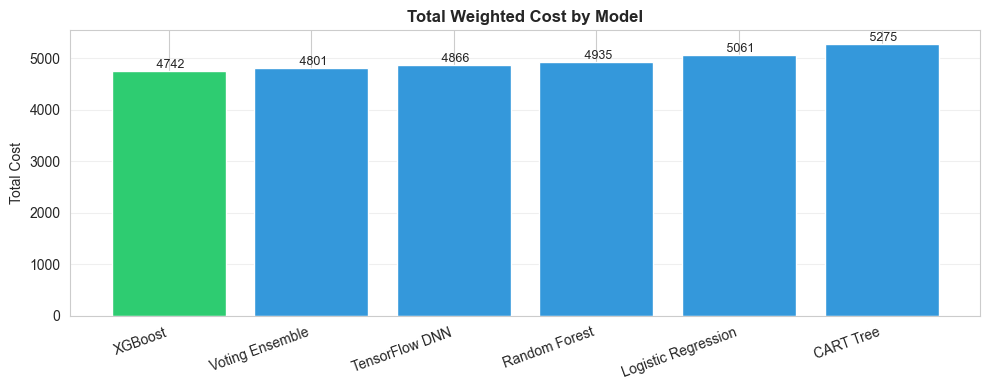

Lowest total cost: XGBoost (Total Cost = 4742, Recall = 0.9016, F1 = 0.7579)


In [15]:
# Business cost analysis -- score each tuned model at its validation-selected threshold
cost_rows = []
for name, model in stage_b_models.items():
    threshold = cost_aware_metrics[name]['best_threshold']
    probs = get_proba(model, X_test_prcsd)
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    total_cost = fn * COST_FN + fp * COST_FP
    cost_rows.append({
        'Model':     name,
        'Threshold': round(threshold, 2),
        'TP':        tp,
        'FP':        fp,
        'FN':        fn,
        'TN':        tn,
        f'FN Cost (×{COST_FN})': fn * COST_FN,
        f'FP Cost (×{COST_FP})': fp * COST_FP,
        'Total Cost': total_cost,
        'Recall':     round(tp / (tp + fn), 4),
        'F1':         round(cost_aware_metrics[name]['f1_left'], 4),
    })

cost_df = pd.DataFrame(cost_rows).sort_values('Total Cost').reset_index(drop=True)
display(cost_df)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(cost_df))]
bars = ax.bar(cost_df['Model'], cost_df['Total Cost'], color=colors, edgecolor='white')
ax.set_title('Total Weighted Cost by Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Cost')
ax.grid(True, axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
for bar, v in zip(bars, cost_df['Total Cost']):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f' {v}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

best = cost_df.iloc[0]
print(f"Lowest total cost: {best['Model']} "
      f"(Total Cost = {best['Total Cost']}, Recall = {best['Recall']}, F1 = {best['F1']})")

In [16]:
# Calibration analysis -- threshold-independent ranking quality of each tuned model
print(f"{'Model':25s}  {'ROC-AUC':>8s}  {'PR-AUC':>7s}")
for name, model in stage_b_models.items():
    probs = get_proba(model, X_test_prcsd)
    print(f"{name:25s}  {roc_auc_score(y_test, probs):>8.4f}  "
          f"{average_precision_score(y_test, probs):>7.4f}")

Model                       ROC-AUC   PR-AUC
Logistic Regression          0.8312   0.8166
CART Tree                    0.8097   0.7733
Random Forest                0.8411   0.8257
XGBoost                      0.8508   0.8392
TensorFlow DNN               0.8423   0.8282
Voting Ensemble              0.8485   0.8352


## Step 9 -- Explainability Analysis with SHAP

This step applies SHAP (SHapley Additive exPlanations) to the two tree-based learners used in the optimized voting ensemble: Random Forest and XGBoost. Applying SHAP to both models provides a more complete explanation of the ensemble components instead of relying on only one learner.

The Random Forest explanation is used as a stability-oriented comparison because it aggregates many decorrelated decision trees. The XGBoost explanation is retained for detailed local interpretation because it is usually the stronger boosted learner and is well supported by `TreeExplainer`. Together, the global and local explanations identify which employee attributes most strongly influence attrition risk predictions.

In [17]:
# Compute SHAP values on a reproducible sample of the test set.
shap_sample_size = min(500, len(X_test_prcsd))
sample_idx = np.random.RandomState(SEED).choice(len(X_test_prcsd), size=shap_sample_size, replace=False)
X_sample = X_test_prcsd[sample_idx]

feature_names = preprocessor.get_feature_names_out()

def positive_class_shap_values(raw_values):
    if isinstance(raw_values, list):
        return raw_values[1]
    raw_values = np.asarray(raw_values)
    if raw_values.ndim == 3:
        return raw_values[:, :, 1]
    return raw_values

rf_explainer = shap.TreeExplainer(best_rf)
rf_shap_values = positive_class_shap_values(rf_explainer.shap_values(X_sample))

xgb_explainer = shap.TreeExplainer(best_xgb)
xgb_shap_values = positive_class_shap_values(xgb_explainer.shap_values(X_sample))

print(f"SHAP values computed for {X_sample.shape[0]} test rows and {X_sample.shape[1]} processed features.")
print("Models explained: Random Forest and XGBoost.")


SHAP values computed for 500 test rows and 33 processed features.
Models explained: Random Forest and XGBoost.


Random Forest global feature importance:


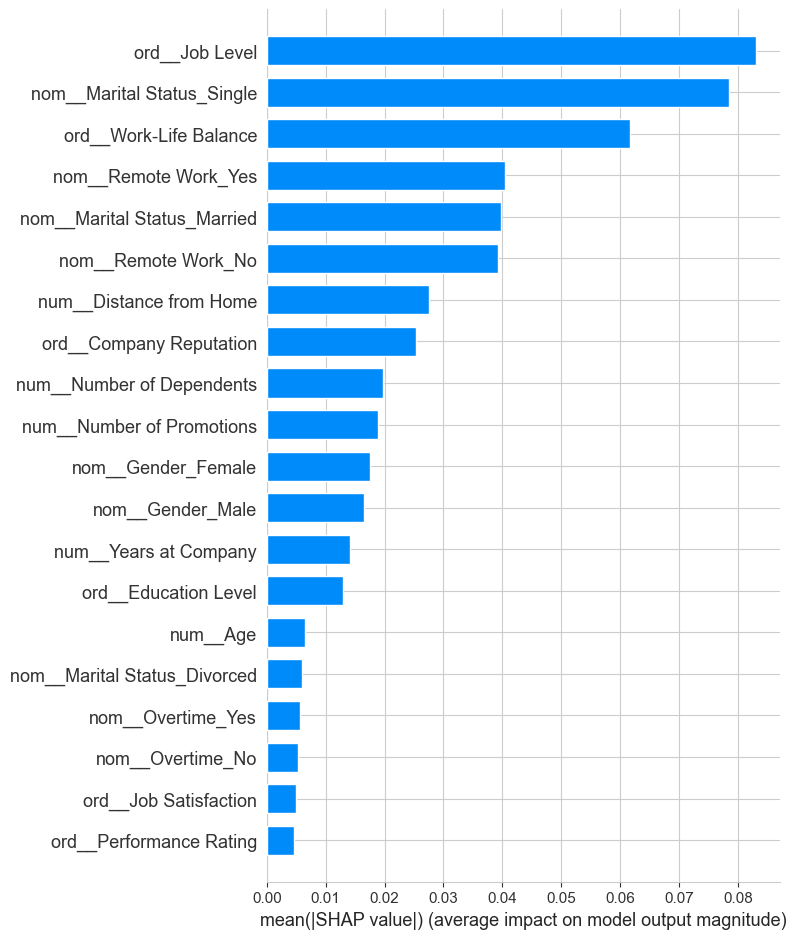


XGBoost global feature importance:


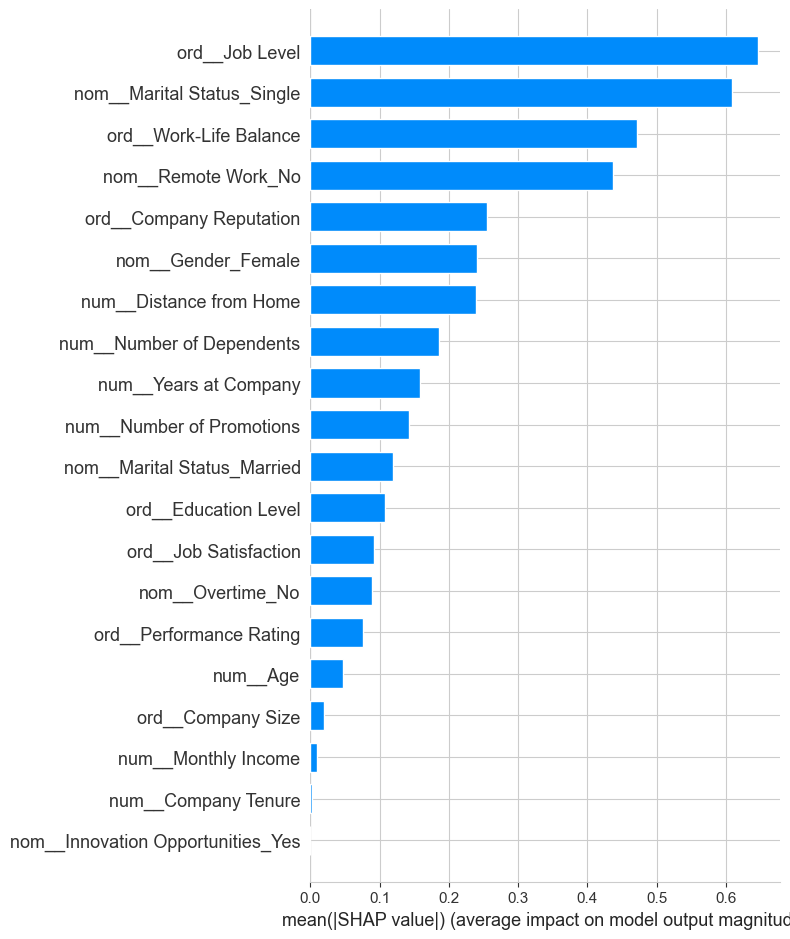

In [18]:
# GLOBAL: Random Forest and XGBoost feature importance
# Bar plot
print("Random Forest global feature importance:")
shap.summary_plot(
    rf_shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type='bar',
    show=True,
)

print("\nXGBoost global feature importance:")
shap.summary_plot(
    xgb_shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type='bar',
    show=True,
)

**Global Feature Importance**

These SHAP values explain the positive class, `Attrition = 1`. Positive SHAP values push a prediction toward attrition, while negative SHAP values push it toward retention.

The bar plots rank features by their average absolute SHAP value across the sampled test employees. Longer bars mean the feature changed model predictions more strongly or more often, but the bar plot does not show whether high or low feature values increase attrition risk.

Random Forest beeswarm plot showing feature direction and magnitude:


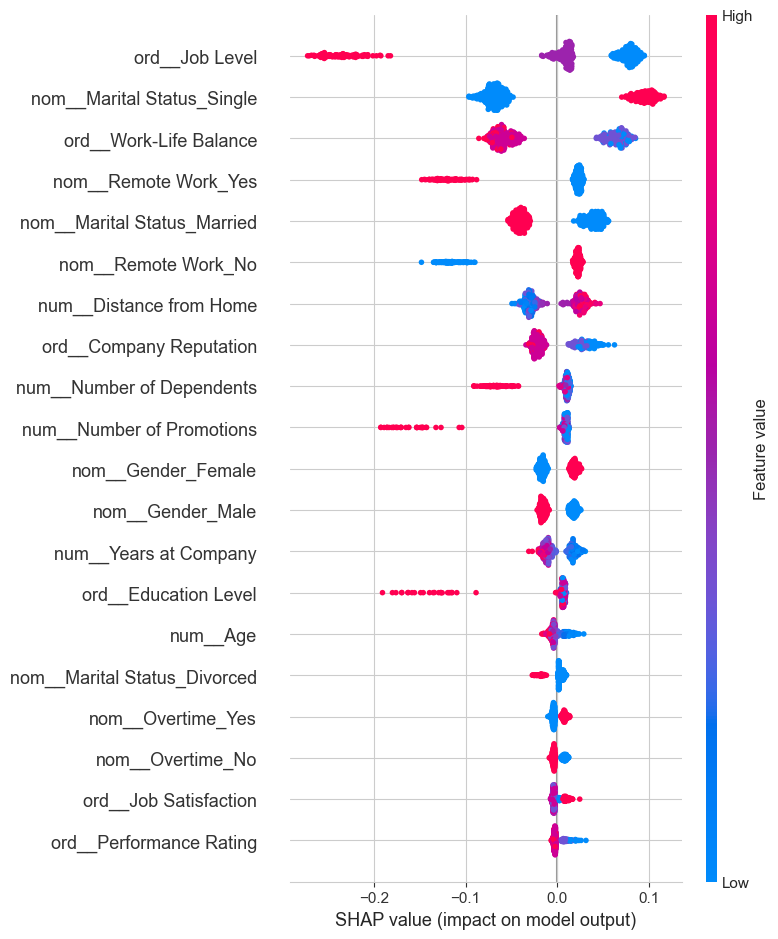


XGBoost beeswarm plot showing feature direction and magnitude:


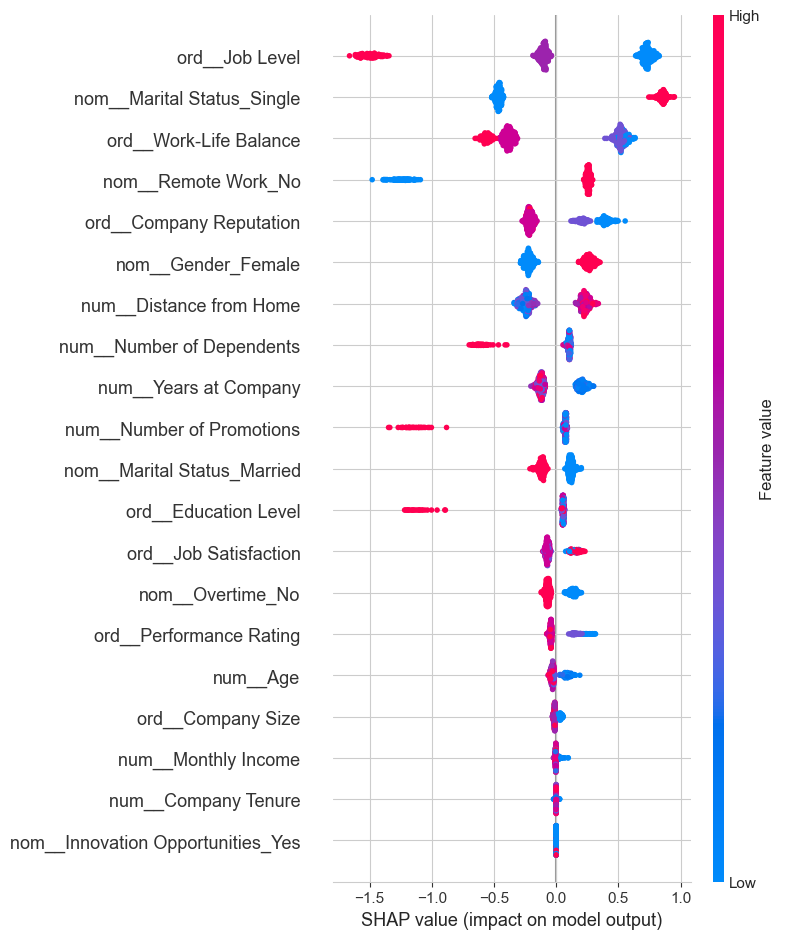

In [19]:
# GLOBAL: Random Forest and XGBoost feature directional effect
# Beeswarm plot
print("Random Forest beeswarm plot showing feature direction and magnitude:")
shap.summary_plot(
    rf_shap_values,
    X_sample,
    feature_names=feature_names,
    show=True,
)

print("\nXGBoost beeswarm plot showing feature direction and magnitude:")
shap.summary_plot(
    xgb_shap_values,
    X_sample,
    feature_names=feature_names,
    show=True,
)

**Feature Direction and Magnitude**

The beeswarm plots show both how important each feature is and which direction it pushes the prediction. Each dot is one employee in the SHAP sample. Dots to the right increase predicted attrition risk, while dots to the left decrease it. Color represents the feature value, where red usually indicates a higher value and blue usually indicates a lower value.

Highest-risk employee in SHAP sample: P(Left) = 0.979
XGBoost local explanation for the selected employee:


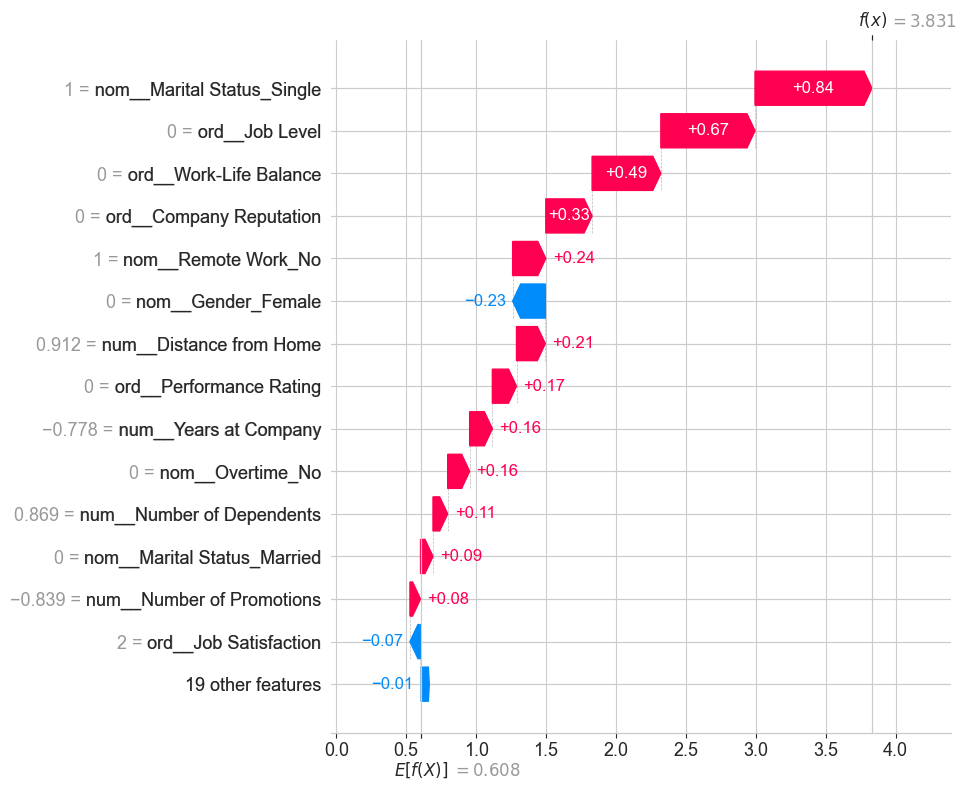

In [20]:
# LOCAL: XGBoost waterfall plot for the highest-risk employee in the SHAP sample.
sample_probs = best_xgb.predict_proba(X_sample)[:, 1]
top_idx = int(np.argmax(sample_probs))

print(f"Highest-risk employee in SHAP sample: P(Left) = {sample_probs[top_idx]:.3f}")
print("XGBoost local explanation for the selected employee:")

xgb_expected_value = xgb_explainer.expected_value
if isinstance(xgb_expected_value, (list, np.ndarray)):
    xgb_expected_value = np.asarray(xgb_expected_value).ravel()[-1]

shap_exp = shap.Explanation(
    values=xgb_shap_values[top_idx],
    base_values=xgb_expected_value,
    data=X_sample[top_idx],
    feature_names=feature_names,
)
shap.waterfall_plot(shap_exp, max_display=15, show=True)

**Local Explanation for One Employee**

The waterfall plot explains one high-risk employee from the SHAP sample. It starts from the model's baseline output and then adds each feature's contribution for that employee. Red features push the prediction toward attrition, while blue features push it toward retention.

## Step 10 -- Counterfactual Explanations with DiCE

This step converts model explanation into prescriptive analysis for the final optimized voting ensemble. While SHAP explains the Random Forest and XGBoost components separately, DiCE is applied to the deployed ensemble pipeline so that the generated recommendations correspond to the final model's decision boundary.

DiCE searches for feasible changes that would move a selected employee from the predicted attrition class to the predicted retention class. To avoid selecting an employee whose prediction is too extreme to produce a realistic intervention, the search prioritizes employees who are predicted to leave but are closest to the optimized ensemble threshold. The generated counterfactuals should be interpreted as model-based decision support, not as automatic HR policy decisions.

In [21]:
# Wrap the preprocessor and final ensemble in one pipeline for DiCE
dice_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', tuned_ensemble),
])

# DiCE uses the raw training data to understand context
df_for_dice = X_tr.reset_index(drop=True).copy()
df_for_dice['Attrition'] = y_tr.reset_index(drop=True).values

d = dice_ml.Data(
    dataframe=df_for_dice,
    continuous_features=numerical_cols,
    outcome_name='Attrition',
)

m = dice_ml.Model(model=dice_pipeline, backend='sklearn')
exp = dice_ml.Dice(d, m, method='genetic')

# Select predicted-left employees nearest to the optimized ensemble threshold
test_probs_ensemble = tuned_ensemble.predict_proba(X_test_prcsd)[:, 1]
ensemble_threshold = best_threshold_ens
predicted_left_idx = np.where(test_probs_ensemble >= ensemble_threshold)[0]

if len(predicted_left_idx) == 0:
    predicted_left_idx = np.argsort(test_probs_ensemble)[-10:]

candidate_idx = sorted(
    predicted_left_idx,
    key=lambda idx: abs(test_probs_ensemble[idx] - ensemble_threshold),
)

# Features that HR can realistically intervene on to prevent attrition
features_to_vary = [
    'Monthly Income', 'Overtime', 'Work-Life Balance', 'Job Satisfaction', 'Number of Promotions', 
    'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Employee Recognition',
]


In [22]:
# Select one reproducible employee case for the DiCE explanation
dice_sample_pool_size = min(10, len(candidate_idx))
dice_sample_pool = np.array(candidate_idx[:dice_sample_pool_size], dtype=int)

if len(dice_sample_pool) == 0:
    raise ValueError("No candidate employees are available for DiCE counterfactual generation.")

dice_rng = np.random.RandomState(SEED)
dice_selected_idx = int(dice_rng.choice(dice_sample_pool))
dice_query = X_test.iloc[[dice_selected_idx]].copy()
dice_selected_prob = float(test_probs_ensemble[dice_selected_idx])

print(f"Selected employee index: {dice_selected_idx}")
print(f"Voting Ensemble P(Left): {dice_selected_prob:.3f}")
print(f"Optimized Voting Ensemble threshold: {ensemble_threshold:.3f}")
display(dice_query)


Selected employee index: 1358
Voting Ensemble P(Left): 0.490
Optimized Voting Ensemble threshold: 0.490


,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition
1358,27,Male,9,Technology,7378,Fair,High,Average,0,No,45,Master’s Degree,Married,4,Mid,Small,19,No,No,Yes,Good,High


**Selected Counterfactual Sample**

The cell above chooses one reproducible employee from the predicted-attrition candidates closest to the optimized ensemble threshold. This makes the DiCE explanation easier to interpret because the selected employee is at a decision boundary where realistic changes are more likely to flip the prediction from attrition to retention.

Use the printed `P(Left)` and threshold to understand the starting point: if `P(Left)` is above the threshold, the ensemble currently classifies this employee as likely to leave.

In [23]:
# Generate prescriptions for the selected employee
try:
    cfs = exp.generate_counterfactuals(
        dice_query,
        total_CFs=3,
        desired_class=0,
        features_to_vary=features_to_vary,
        verbose=False,
    )
    cf_df = cfs.cf_examples_list[0].final_cfs_df
    if cf_df is None or cf_df.empty:
        print("No feasible counterfactual prescription was found for the selected sample.")
    else:
        print("Counterfactual prescriptions generated by DiCE:")
        cfs.visualize_as_dataframe(show_only_changes=True)
except Exception as exc:
    print(f"No feasible counterfactual prescription was found for the selected sample: {exc}")


100%|██████████| 1/1 [00:01<00:00,  1.99s/it]

Counterfactual prescriptions generated by DiCE:
Query instance (original outcome : 0)


,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,27,Male,9,Technology,7378,Fair,High,Average,0,No,45,Master’s Degree,Married,4,Mid,Small,19,No,No,Yes,Good,High,0



Diverse Counterfactual set (new outcome: 0)


,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,No,-,-,-
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Yes,-,-,-,-,-
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,No,-,-,-


**How to Read the DiCE Output**

The cell above asks DiCE for up to three counterfactual versions of the selected employee. Only HR-actionable fields are allowed to vary, such as income, overtime, work-life balance, satisfaction, remote work, opportunities, and recognition.

The displayed table uses `show_only_changes=True`, so unchanged fields are hidden with dashes. Each row is one model-suggested set of changes that would move the final voting ensemble from predicting attrition to predicting retention. These are explanation examples for decision support, not automatic HR policy instructions.

## Step 11 -- Model Artifact Export and Deployment Outputs

This step saves the minimum artifacts required to reproduce the final scoring workflow: the fitted preprocessor, the tuned tree-based models, the optimized voting ensemble, and the final decision threshold. The preprocessor and threshold are necessary because new employee records must receive the same transformations and classification rule used during evaluation.

The individual Random Forest and XGBoost models are retained for auditability and future comparison, while the voting ensemble represents the primary deployment model. The exported risk-score CSV is a project deliverable that demonstrates how the trained model can be converted into an HR-facing attrition-risk report.

In [24]:
os.makedirs('artifacts', exist_ok=True)

# Save preprocessor, tuned models, and threshold
joblib.dump(preprocessor, 'artifacts/preprocessor.joblib')
joblib.dump(best_rf, 'artifacts/best_rf.joblib')
joblib.dump(best_xgb, 'artifacts/best_xgb.joblib')
joblib.dump(tuned_ensemble, 'artifacts/tuned_ensemble.joblib')

with open('artifacts/threshold.txt', 'w') as f:
    f.write(f"{best_threshold_ens:.4f}\n")

# Score the entire test set and export a flight-risk CSV for HR
risk_df = X_test.reset_index(drop=True).copy()
risk_df['P_Left']     = ensemble_test_probs
risk_df['Predicted']  = np.where(ensemble_test_probs >= best_threshold_ens, 'Left', 'Stayed')
risk_df['Risk Band']  = pd.cut(
    ensemble_test_probs,
    bins=[-0.001, 0.30, 0.60, 1.0],
    labels=['Low', 'Medium', 'High'],
)
risk_df.to_csv('artifacts/risk_scores.csv', index=False)

print("Artifacts saved to ./artifacts/:")
print("  - preprocessor.joblib (the ColumnTransformer)")
print("  - best_rf.joblib (tuned cost-aware Random Forest)")
print("  - best_xgb.joblib (tuned cost-aware XGBoost)")
print("  - tuned_ensemble.joblib (soft-voting ensemble)")
print("  - threshold.txt (cost-optimal decision threshold)")
print("  - risk_scores.csv (test-set predictions + risk bands)")

print("\nRisk band distribution (test set):")
print(risk_df['Risk Band'].value_counts().sort_index())

Artifacts saved to ./artifacts/:
  - preprocessor.joblib (the ColumnTransformer)
  - best_rf.joblib (tuned cost-aware Random Forest)
  - best_xgb.joblib (tuned cost-aware XGBoost)
  - tuned_ensemble.joblib (soft-voting ensemble)
  - threshold.txt (cost-optimal decision threshold)
  - risk_scores.csv (test-set predictions + risk bands)

Risk band distribution (test set):
Risk Band
Low       2545
Medium    4335
High      8020
Name: count, dtype: int64
